# **CAPÍTULO 1: Fundamentos Físico-Matemáticos de la Señal Acústica**

Para que un sistema computacional procese música, primero debemos entender la naturaleza matemática de la señal. A diferencia de las representaciones simbólicas (como las partituras o los archivos MIDI), las representaciones de audio no especifican eventos musicales explícitos, sino que codifican ondas acústicas generadas por oscilaciones de la presión del aire.

Matemáticamente, modelamos una señal de audio analógica como una función continua $f(t) \in L^2(\mathbb{R})$. Para que esta señal sea procesable computacionalmente, aplicamos el **Teorema de Muestreo de Nyquist-Shannon**. Si la señal está limitada en banda, puede ser perfectamente reconstruida a partir de su versión discretizada si la frecuencia de muestreo es al menos el doble de la frecuencia máxima.

Dado que las señales musicales son mezclas complejas, extraer información relevante de la forma de onda pura constituye un problema difícil. Por ello, recurrimos al **Análisis de Fourier**, el cual descompone la señal en funciones sinusoidales con un significado físico directo en términos de frecuencia. En la práctica computacional, utilizamos la Transformada de Fourier a Corto Plazo (STFT) para evaluar cómo evoluciona el espectro armónico a lo largo del tiempo, transformando la señal unidimensional en una matriz bidimensional conocida como espectrograma.

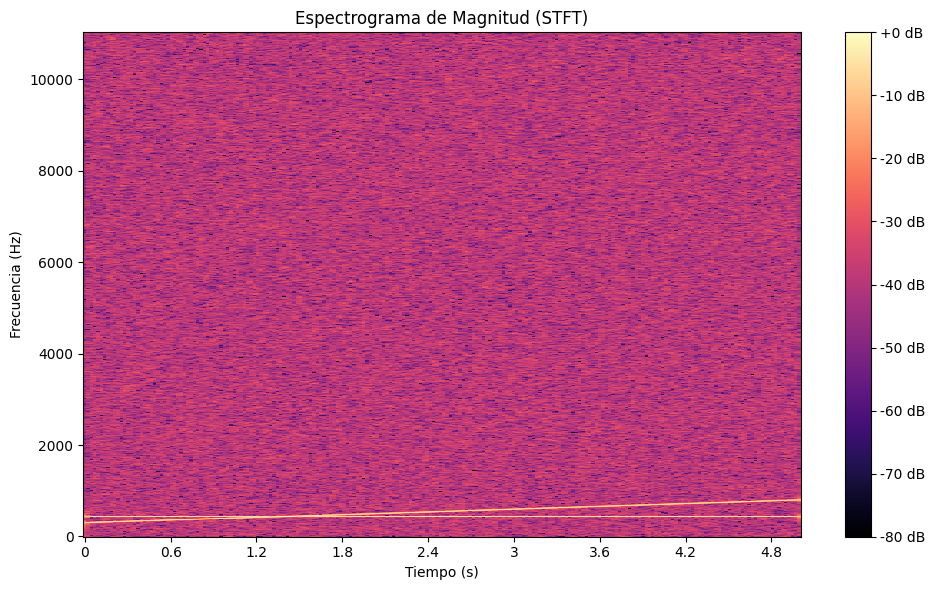

In [1]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter

# Generación de señal matemática pura: 2 tonos que cambian en el tiempo + ruido
sr=22050 # Frecuencia de muestreo (Nyquist=11025 Hz)
t=np.linspace(0, 5, sr*5, endpoint=False) # 5 segundos

# Señal: Frecuencia que sube (Chirp) y un tono constante
señal=np.sin(2*np.pi*440*t) + np.sin(2*np.pi*(300 + 50*t)*t)
señal+=0.5*np.random.randn(len(t)) # Ruido gaussiano que dificulta la extracción

# Transformada de Fourier a Corto Plazo (STFT)
n_fft=2048
hop_length=512

# Obtención de la matriz compleja y almacenamiento (espectrograma)
S_complex=librosa.stft(y=señal, n_fft=n_fft, hop_length=hop_length)
S_mag=np.abs(S_complex) #Calculamos el módulo para pasar del plano complejo a R
S_db=librosa.amplitude_to_db(S_mag, ref=np.max)

# Visualización del espectograma
plt.figure(figsize=(10, 6))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time',
                         y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title('Espectrograma de Magnitud (STFT)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Frecuencia (Hz)')
plt.tight_layout()
plt.show()

# **CAPÍTULO 2: Enfoques Clásicos y la Rigidez de la Geometría**

Una vez obtenida la matriz del espectrograma, el objetivo del *Audio Fingerprinting* es extraer una firma única. Históricamente, antes de la llegada del Deep Learning, este problema se abordaba mediante heurísticas geométricas.

In [2]:
pip install librosa matplotlib numpy scipy

## 2.1. Audio fingerprinting. Mapa de constelaciones
El método clásico más famoso consiste en buscar máximos locales en el espectrograma, creando una matriz dispersa de unos y ceros. Matemáticamente, definimos un punto $(t, f)$ como un pico si su magnitud es estrictamente mayor que la de todos sus vecinos en un entorno topológico.

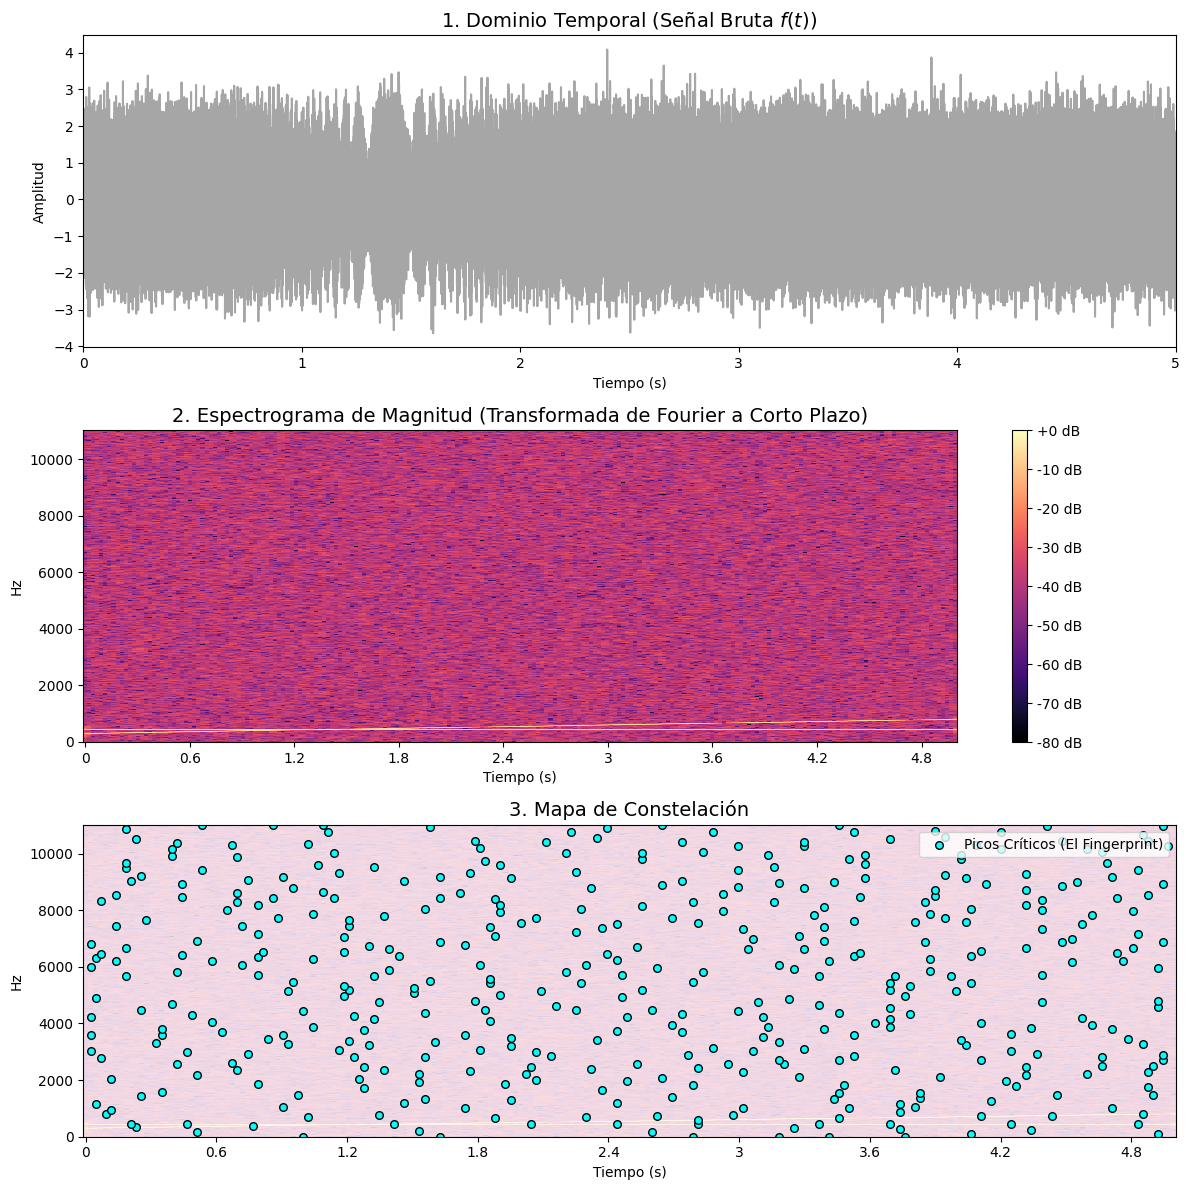


Características:
 - Dimensiones del espectrograma: (1025, 216)->221400 valores reales
 - Número de picos extraídos en la constelación: 434 coordenadas discretas
 - Ratio de compresión teórico inicial: 255.1x


In [3]:
# 2.1 AUDIO FINGERPRINTING. MAPA DE CONSTELACIONES

def extract_peaks(spectrogram, size=15, threshold=-40):
    """
    Función que busca máximos locales en la matriz del espectrograma usando
    filtros morfológicos. Un máximo local es un punto que tiene la energía
    máxima en un entorno
    """
    local_max=maximum_filter(spectrogram, size=size) == spectrogram
    background=(spectrogram > threshold)
    peaks=local_max & background
    return peaks

# Extracción del Fingerprint (Formato: mapa de constelaciones)
constellation_map=extract_peaks(S_db, size=20, threshold=-30)
y_peaks, x_peaks=np.where(constellation_map)

# Visualización
fig, ax=plt.subplots(3, 1, figsize=(12, 12))
# Panel 1: El Dominio del Tiempo
ax[0].plot(t, señal, color='gray', alpha=0.7)
ax[0].set_title("1. Dominio Temporal (Señal Bruta $f(t)$)", fontsize=14)
ax[0].set_ylabel("Amplitud")
ax[0].set_xlabel("Tiempo (s)")
ax[0].set_xlim(0, 5)
# Panel 2: El Dominio de la Frecuencia
img=librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time',
                             y_axis='linear', ax=ax[1], cmap='magma')
ax[1].set_title(
    "2. Espectrograma de Magnitud (Transformada de Fourier a Corto Plazo)",
    fontsize=14)
ax[1].set_xlabel("Tiempo (s)")
fig.colorbar(img, ax=ax[1], format="%+2.0f dB")
# Panel 3: Fingerprinting
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis='time',
                         y_axis='linear', ax=ax[2], cmap='magma', alpha=0.2)
tiempos_picos = librosa.frames_to_time(x_peaks, sr=sr, hop_length=hop_length)
frecuencias_picos = librosa.fft_frequencies(sr=sr, n_fft=n_fft)[y_peaks]
ax[2].scatter(tiempos_picos, frecuencias_picos, color='cyan', s=30,
              edgecolor='black', label="Picos Críticos (El Fingerprint)")
ax[2].set_title("3. Mapa de Constelación", fontsize=14)
ax[2].set_xlabel("Tiempo (s)")
ax[2].legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Características:")
print(f" - Dimensiones del espectrograma: {S_db.shape}->{S_db.size} valores reales")
print(f" - Número de picos extraídos en la constelación: {len(x_peaks)} coordenadas discretas")
print(f" - Ratio de compresión teórico inicial: {S_db.size / (len(x_peaks) * 2):.1f}x")

## 2.2. Flexibilidad Temporal: Pearson vs Dynamic Time Warping (DTW)

Esta constelación es excelente para copias exactas. Sin embargo, cuando tratamos con covers, el tempo rara vez es idéntico. Comparar matrices de forma rígida (usando la Correlación de Pearson) falla drásticamente.

Para intentar solucionar esto en el procesamiento clásico, se utiliza Dynamic Time Warping (DTW). Es un algoritmo que encuentra el camino de coste mínimo para alinear dos series temporales, permitiendo que la señal se "estire" elásticamente.

A continuación, descargamos canciones reales de la base de datos **MelodySim** y evaluamos cómo se comportan el Cromagrama (notas), el Espectrograma Mel (timbre) y los Picos frente a Covers y Plagios, comparando la comparación rígida (Pearson) vs elástica (DTW).

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/539 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/45 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/539 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/45 [00:00<?, ?it/s]


Comparativa experimental: PEARSON vs DTW

MÉTODO 1 - Chroma/Notas:
 - Cover  | Pearson:   6.7% -> DTW:  25.4%
 - Plagio | Pearson:  18.7% -> DTW:  38.8%

MÉTODO 2 - Mel/Timbre:
 - Cover  | Pearson:  72.7% -> DTW:  74.8%
 - Plagio | Pearson:  73.4% -> DTW:  88.8%

MÉTODO 3 - Picos/Shazam:
 - Cover  | Pearson:   1.9% -> DTW:  17.5%
 - Plagio | Pearson:   0.0% -> DTW:  25.5%


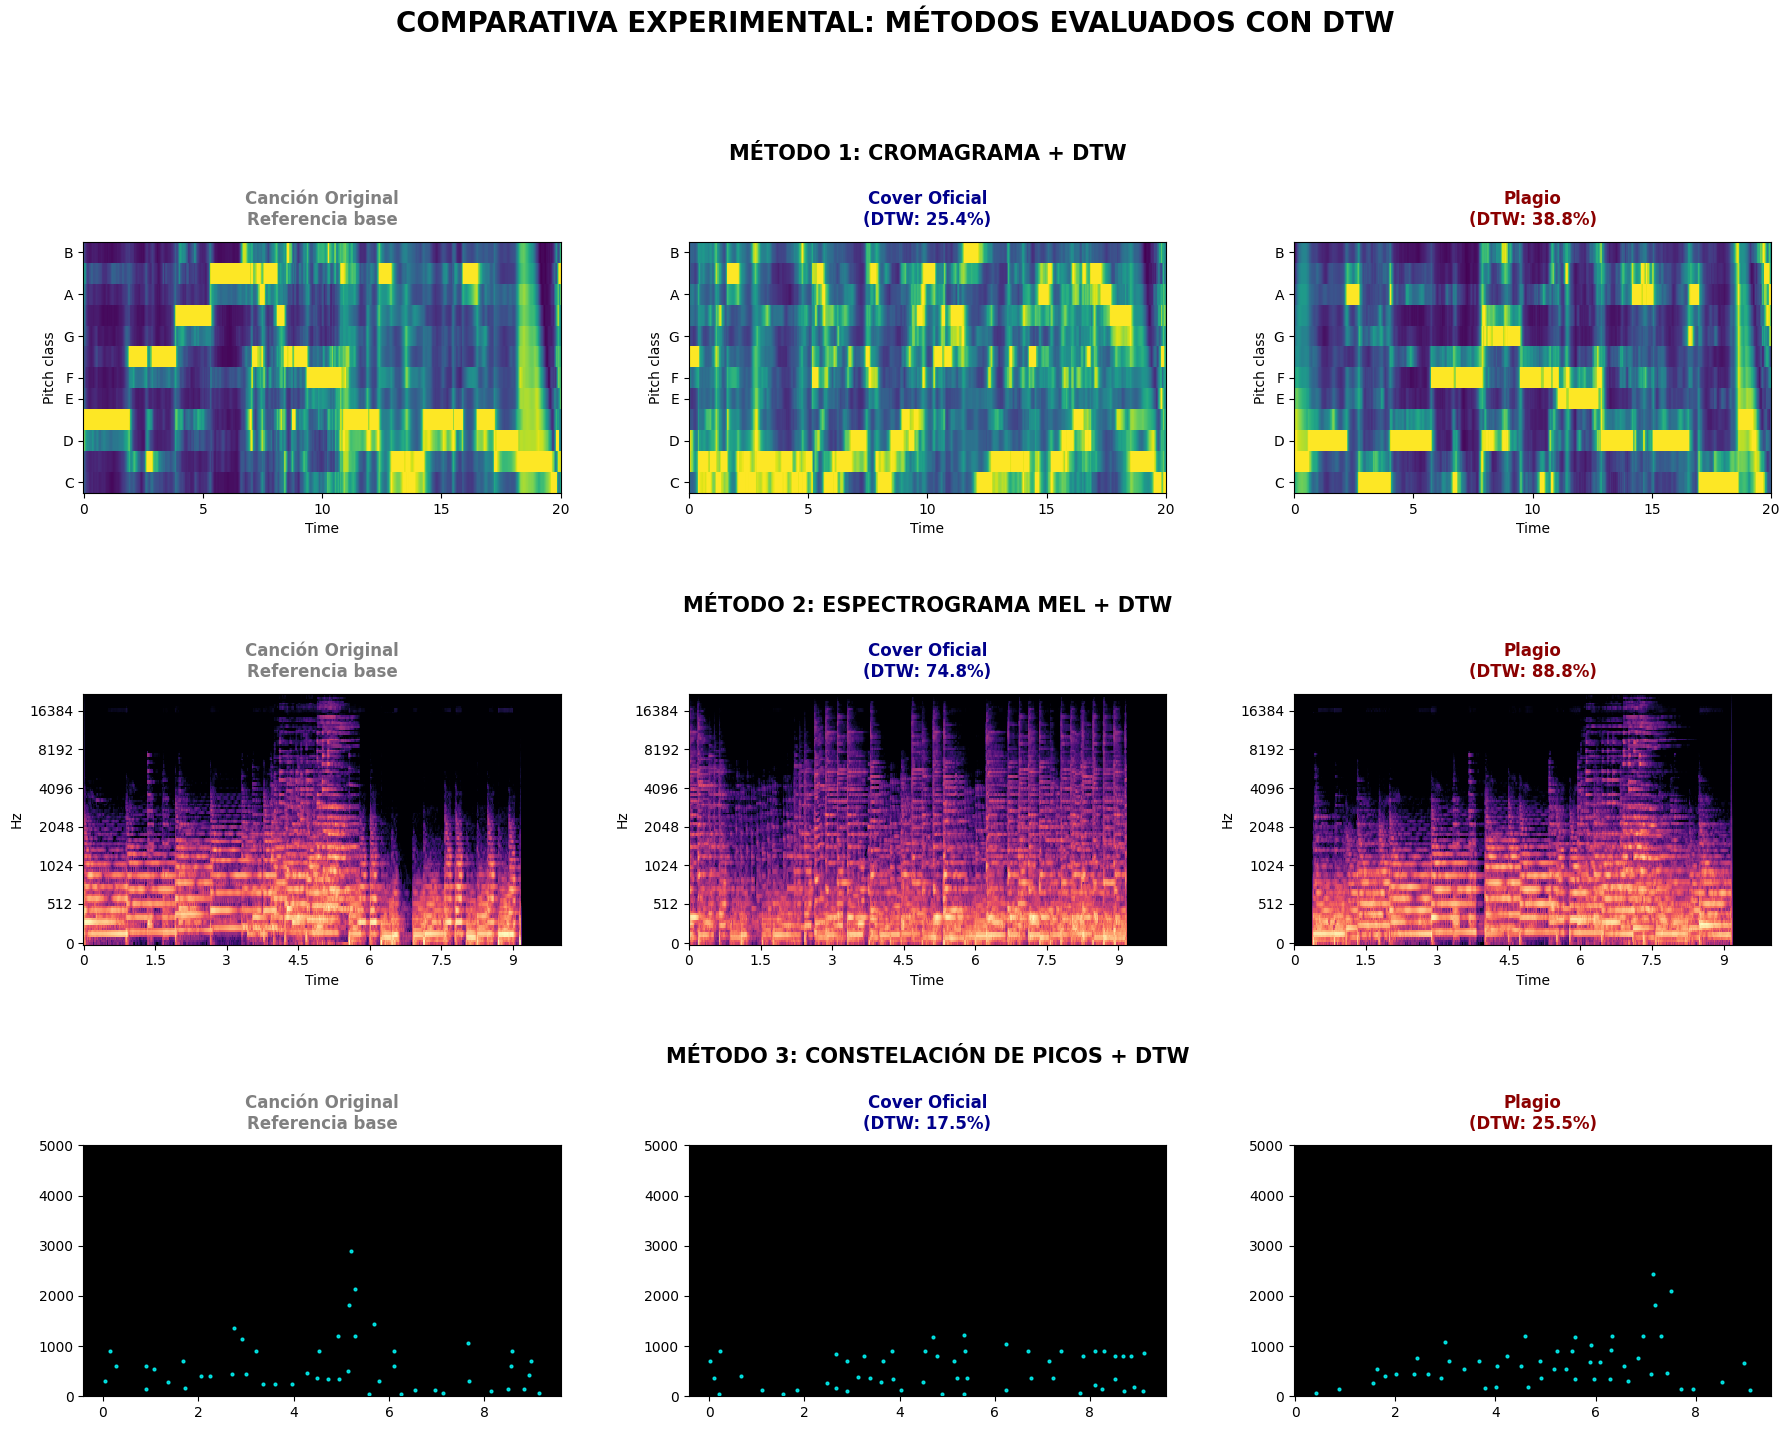

In [4]:
# 2.2 FLEXIBILIDAD TEMPORAL: PEARSON VS DTW CON DATOS REALES
import os
from datasets import load_dataset
import warnings
warnings.filterwarnings("ignore")

def cargar_audios_melodysim(duration=10.0):
    try:
        dataset_stream=load_dataset("amaai-lab/MelodySim",
                                    split="train", streaming=True)
        iterator=iter(dataset_stream)
        fila_orig, fila_cover, fila_plagio=next(iterator), next(iterator), next(iterator)
        claves=list(fila_orig.keys())
        col_audio=next((k for k in claves if 'audio' in k.lower()), claves[0])
        y_orig=np.array(fila_orig[col_audio]['array'], dtype=np.float32)
        sr=fila_orig[col_audio]['sampling_rate']
        y_cov=np.array(fila_cover[col_audio]['array'], dtype=np.float32)
        y_pla=np.array(fila_plagio[col_audio]['array'], dtype=np.float32)
        max_length=int(sr * duration)
        def ajustar_longitud(y):
            if len(y) > max_length: return y[:max_length]
            elif len(y) < max_length: return np.pad(y, (0, max_length - len(y)))
            return y
        return ajustar_longitud(y_orig), ajustar_longitud(y_cov), ajustar_longitud(y_pla), sr
    except Exception as e:
        print(f" ERROR: {e}")
        return None, None, None, None

def extraer_chroma(audio, sr):
  return librosa.feature.chroma_cqt(y=audio, sr=sr, n_chroma=12)
def extraer_mel(audio, sr):
  return librosa.power_to_db(
      librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128), ref=np.max)
def extraer_picos(audio, sr, threshold=-20, neighborhood_size=25):
    spec_db=librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
    local_max=maximum_filter(spec_db, size=neighborhood_size) == spec_db
    return (local_max & (spec_db > threshold)).astype(float)

def calcular_similitud_porcentaje(m1, m2):
    min_cols=min(m1.shape[1], m2.shape[1])
    vec1, vec2=m1[:, :min_cols].flatten(), m2[:, :min_cols].flatten()
    if np.std(vec1) == 0 or np.std(vec2) == 0: return 0.0
    return max(0.0, np.corrcoef(vec1, vec2)[0, 1] * 100)

def calcular_similitud_dtw(m1, m2):
    try:
        D, wp=librosa.sequence.dtw(m1, m2, metric='euclidean')
        v1, v2=m1[:, wp[:, 0]].flatten(), m2[:, wp[:, 1]].flatten()
        if np.std(v1) == 0 or np.std(v2) == 0: return 0.0
        return max(0.0, np.corrcoef(v1, v2)[0, 1] * 100)
    except:
        return 0.0

# Ejecución
y_orig, y_cov, y_pla, sr_real=cargar_audios_melodysim(duration=10.0)
fp_chroma=[extraer_chroma(y_orig, sr_real), extraer_chroma(y_cov, sr_real), extraer_chroma(y_pla, sr_real)]
fp_mel=[extraer_mel(y_orig, sr_real), extraer_mel(y_cov, sr_real), extraer_mel(y_pla, sr_real)]
fp_peaks=[extraer_picos(y_orig, sr_real), extraer_picos(y_cov, sr_real), extraer_picos(y_pla, sr_real)]

# Visualización
print("\n" + "="*80)
print("Comparativa experimental: PEARSON vs DTW")
print("\nMÉTODO 1 - Chroma/Notas:")
print(f" - Cover  | Pearson: {calcular_similitud_porcentaje(fp_chroma[0], fp_chroma[1]):>5.1f}% -> DTW: {calcular_similitud_dtw(fp_chroma[0], fp_chroma[1]):>5.1f}%")
print(f" - Plagio | Pearson: {calcular_similitud_porcentaje(fp_chroma[0], fp_chroma[2]):>5.1f}% -> DTW: {calcular_similitud_dtw(fp_chroma[0], fp_chroma[2]):>5.1f}%")
print("\nMÉTODO 2 - Mel/Timbre:")
print(f" - Cover  | Pearson: {calcular_similitud_porcentaje(fp_mel[0], fp_mel[1]):>5.1f}% -> DTW: {calcular_similitud_dtw(fp_mel[0], fp_mel[1]):>5.1f}%")
print(f" - Plagio | Pearson: {calcular_similitud_porcentaje(fp_mel[0], fp_mel[2]):>5.1f}% -> DTW: {calcular_similitud_dtw(fp_mel[0], fp_mel[2]):>5.1f}%")
print("\nMÉTODO 3 - Picos/Shazam:")
print(f" - Cover  | Pearson: {calcular_similitud_porcentaje(fp_peaks[0], fp_peaks[1]):>5.1f}% -> DTW: {calcular_similitud_dtw(fp_peaks[0], fp_peaks[1]):>5.1f}%")
print(f" - Plagio | Pearson: {calcular_similitud_porcentaje(fp_peaks[0], fp_peaks[2]):>5.1f}% -> DTW: {calcular_similitud_dtw(fp_peaks[0], fp_peaks[2]):>5.1f}%")

fig, ax=plt.subplots(3, 3, figsize=(18, 15))
titulos_columnas=['Canción Original\nReferencia base', 'Cover Oficial', 'Plagio']
titulos_metodos=["MÉTODO 1: CROMAGRAMA + DTW", "MÉTODO 2: ESPECTROGRAMA MEL + DTW", "MÉTODO 3: CONSTELACIÓN DE PICOS + DTW"]
similitudes_grafico = [
    [None, calcular_similitud_dtw(fp_chroma[0], fp_chroma[1]), calcular_similitud_dtw(fp_chroma[0], fp_chroma[2])],
    [None, calcular_similitud_dtw(fp_mel[0], fp_mel[1]), calcular_similitud_dtw(fp_mel[0], fp_mel[2])],
    [None, calcular_similitud_dtw(fp_peaks[0], fp_peaks[1]), calcular_similitud_dtw(fp_peaks[0], fp_peaks[2])]
]

def plot_master(fp, ax_obj, col_idx, fila_idx, tipo, sr):
    if tipo == 'chroma': librosa.display.specshow(fp, y_axis='chroma', x_axis='time', ax=ax_obj, cmap='viridis')
    elif tipo == 'mel': librosa.display.specshow(fp, y_axis='mel', x_axis='time', ax=ax_obj, cmap='magma', sr=sr)
    elif tipo == 'peaks':
        f_idx, t_idx=np.where(fp == 1.0)
        ax_obj.scatter(librosa.frames_to_time(t_idx, sr=sr), librosa.fft_frequencies(sr=sr)[f_idx], color='cyan', s=4, alpha=0.8)
        ax_obj.set_facecolor('black'); ax_obj.set_ylim(0, 5000)

    color_titulo='darkblue' if col_idx == 1 else 'darkred' if col_idx == 2 else 'gray'
    texto_titulo=titulos_columnas[col_idx] + (f"\n(DTW: {similitudes_grafico[fila_idx][col_idx]:.1f}%)" if col_idx > 0 else "")
    ax_obj.set_title(texto_titulo, fontsize=12, color=color_titulo, pad=12, fontweight='bold')
    if col_idx == 1: ax_obj.annotate(titulos_metodos[fila_idx], xy=(0.5, 1.35), xycoords='axes fraction', ha='center', va='center', fontsize=15, fontweight='black')

for i in range(3):
    plot_master(fp_chroma[i], ax[0, i], i, 0, 'chroma', sr_real)
    plot_master(fp_mel[i], ax[1, i], i, 1, 'mel', sr_real)
    plot_master(fp_peaks[i], ax[2, i], i, 2, 'peaks', sr_real)

plt.suptitle('COMPARATIVA EXPERIMENTAL: MÉTODOS EVALUADOS CON DTW', fontsize=20, fontweight='black', y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.subplots_adjust(hspace=0.8)
plt.show()

## 2.3. Veredicto: El Salto al Aprendizaje de Representaciones

Como demuestra el experimento, ninguno de los métodos tradicionales es infalible:
1. El DTW salva las notas corrigiendo el tiempo, pero fracasa si el cover cambia los instrumentos (timbre).
2. En matrices densas (Mel), el DTW es tan elástico que a veces genera **falsos positivos**, alineando ruidos que no tienen nada que ver.
3. Con **Constelaciones de Picos**, los algoritmos continuos como DTW colapsan matemáticamente al intentar alinear matrices llenas de ceros.

Comparar matrices de audio "píxel por píxel" o forzar su alineación elástica no resuelve el problema. Es necesario un sistema capaz de ignorar el ruido y entender la "semántica" del espectrograma. Por ello, en el siguiente capítulo damos el salto al Deep Learning.

# **CAPÍTULO 3: Aprendizaje de Representaciones (Deep Metric Learning)**

Para superar la rigidez geométrica demostrada en el capítulo anterior, abandonamos la comparación axiomática y adoptamos un enfoque de **Inteligencia Artificial**. El objetivo es construir una función no lineal continua, parametrizada por una red neuronal ($f_\theta$), que proyecte los espectrogramas desde su alta dimensionalidad original a un espacio métrico reducido (un vector $v \in \mathbb{R}^{128}$ llamado *Fingerprint*).

Para esculpir la topología de este espacio, utilizamos la **Triplet Margin Loss**. Esta función de pérdida fuerza a la red a actualizar sus pesos de modo que la distancia entre versiones de una misma canción sea mínima, mientras empuja a canciones distintas hacia hemisferios opuestos de una hiperesfera matemática.



## 3.1. Preparación del Espacio de Datos
En primer lugar, dividimos ortogonalmente nuestro universo de espectrogramas en dos conjuntos (Train y Test) garantizando que la red nunca evalúe su precisión con canciones que ya ha memorizado.

In [5]:
# 3.1 PREPARACIÓN DEL ESPACIO DE DATOS
import os
import random
import re
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from google.colab import drive
import shutil
import math
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models
from PIL import Image

# Forzamos reproducibilidad
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

# Conexión con Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
ruta_drive='/content/drive/MyDrive/dataset_Espectrogramas'
RUTA_DATASET='/content/dataset_Espectrogramas_Local'

# Copiamos los datos al disco local
if not os.path.exists(RUTA_DATASET):
    shutil.copytree(ruta_drive, RUTA_DATASET)
    print("Dataset guardado en el disco local")
else:
    print("Dataset ya estaba en el disco local.")

class SpectrogramPNGDataset(Dataset):
    def __init__(self, ruta_carpeta, modo="train", particion_train=0.8):
        self.ruta=ruta_carpeta
        self.archivos=[f for f in os.listdir(ruta_carpeta) if f.endswith('.png')]
        self.modo=modo
        self.transform=transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])
        self.agrupacion_canciones=self._agrupar_por_cancion()
        todas_las_canciones=list(self.agrupacion_canciones.keys())
        todas_las_canciones.sort()
        random.Random(42).shuffle(todas_las_canciones)
        corte=int(len(todas_las_canciones)*particion_train)
        self.mis_canciones=todas_las_canciones[:corte] if self.modo == "train" else todas_las_canciones[corte:]
        self.lista_ids_validos=[k for k in self.mis_canciones if len(self.agrupacion_canciones[k]) >= 2]

        print(f" - [Modo {self.modo.upper()}] Universo : {len(self.mis_canciones)} canciones | Válidas para Tríos: {len(self.lista_ids_validos)}")

    def _agrupar_por_cancion(self):
        grupos = {}
        for f in self.archivos:
            nombre=f.replace('.png', '')
            if " - " in nombre: nombre = nombre.split(" - ", 1)[1]
            nombre_limpio=re.sub(r'[\s_]*\(?V[-A-Z]+\)?$', '', nombre).strip()
            if nombre_limpio not in grupos: grupos[nombre_limpio] = []
            grupos[nombre_limpio].append(f)
        return grupos

    def __len__(self): return len(self.lista_ids_validos)

    def __getitem__(self, idx):
        id_actual=self.lista_ids_validos[idx]
        variantes=self.agrupacion_canciones[id_actual]
        v_anc, v_pos=random.sample(variantes, 2)
        id_neg=random.choice([i for i in self.mis_canciones if i != id_actual])
        v_neg=random.choice(self.agrupacion_canciones[id_neg])
        return (self.transform(Image.open(os.path.join(self.ruta, v_anc))),
                self.transform(Image.open(os.path.join(self.ruta, v_pos))),
                self.transform(Image.open(os.path.join(self.ruta, v_neg))))

# Instancia de los cargadores de memoria
dataset_train=SpectrogramPNGDataset(RUTA_DATASET, modo="train")
dataset_test=SpectrogramPNGDataset(RUTA_DATASET, modo="test")
dataloader_train=DataLoader(dataset_train, batch_size=16, shuffle=True)
dataloader_val=DataLoader(dataset_test, batch_size=16, shuffle=False)

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Motor de cálculo activado: {device}")

# Capa KAN (Kolmogorov-Arnold Network) - Implementación Matemática
class CapaKAN(nn.Module):
    """
    Capa KAN Simplificada usando una base de Fourier.
    En lugar de usar pesos fijos y activaciones en los nodos (como MLP),
    aprende una función continua (combinación de senos) en cada arista.
    """
    def __init__(self, in_features, out_features, num_bases=5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_bases = num_bases

        # Pesos para la combinación lineal de las funciones de Fourier
        self.pesos_base = nn.Parameter(torch.Tensor(out_features, in_features, num_bases))
        # Pesos lineales tradicionales (para estabilizar el aprendizaje)
        self.pesos_lineales = nn.Parameter(torch.Tensor(out_features, in_features))

        # Inicialización de pesos
        nn.init.kaiming_uniform_(self.pesos_base, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.pesos_lineales, a=math.sqrt(5))

    def forward(self, x):
        # 1. Parte lineal estándar
        salida_lineal = F.linear(F.silu(x), self.pesos_lineales)

        # 2. Parte no lineal KAN (Aprende la función en la arista)
        # Expandimos x para aplicar las bases de Fourier: sin(n * x)
        n = torch.arange(1, self.num_bases + 1, device=x.device).float()
        bases = torch.sin(x.unsqueeze(-1) * n) # Forma: (Batch, Entradas, Num_Bases)

        # Aplanamos para multiplicar eficientemente
        bases_flat = bases.view(x.size(0), -1)
        pesos_flat = self.pesos_base.view(self.out_features, -1)
        salida_kan = F.linear(bases_flat, pesos_flat)

        # La salida es la evaluación completa del Teorema de Kolmogorov-Arnold
        return salida_lineal + salida_kan

Mounted at /content/drive
Dataset guardado en el disco local
 - [Modo TRAIN] Universo : 352 canciones | Válidas para Tríos: 152
 - [Modo TEST] Universo : 89 canciones | Válidas para Tríos: 35
Motor de cálculo activado: cuda


## 3.2. Definición de Topologías: CNN MLP, CNN KAN, AlexNet, EfficientNet y Motor Universal

Para evaluar qué arquitectura extrae mejor las características musicales, definimos tres modelos de complejidad ascendente. Para garantizar una comparativa justa y evitar repetir código computacional, abstraemos la lógica de optimización (el descenso por el gradiente y el *Early Stopping*) en una única función universal. Esta función registrará el progreso del entrenamiento para su posterior análisis visual.


 Arquitectura: CNN Clásica (MLP)
Época 01 | Train Loss: 0.9901 | Val Loss: 0.9764
Época 02 | Train Loss: 1.0057 | Val Loss: 0.9802
 Paciencia 1/10
Época 03 | Train Loss: 1.0082 | Val Loss: 0.9808
 Paciencia 2/10
Época 04 | Train Loss: 1.0099 | Val Loss: 0.9606
Época 05 | Train Loss: 0.9807 | Val Loss: 0.9365
Época 06 | Train Loss: 0.9717 | Val Loss: 0.8730
Época 07 | Train Loss: 0.9150 | Val Loss: 0.7862
Época 08 | Train Loss: 0.6898 | Val Loss: 0.8324
 Paciencia 1/10
Época 09 | Train Loss: 0.5814 | Val Loss: 0.5375
Época 10 | Train Loss: 0.6418 | Val Loss: 0.5415
 Paciencia 1/10
Época 11 | Train Loss: 0.6285 | Val Loss: 0.4191
Época 12 | Train Loss: 0.6125 | Val Loss: 0.5940
 Paciencia 1/10
Época 13 | Train Loss: 0.5707 | Val Loss: 0.6447
 Paciencia 2/10
Época 14 | Train Loss: 0.5614 | Val Loss: 0.5247
 Paciencia 3/10
Época 15 | Train Loss: 0.6190 | Val Loss: 0.4090
Época 16 | Train Loss: 0.5568 | Val Loss: 0.6071
 Paciencia 1/10
Época 17 | Train Loss: 0.5378 | Val Loss: 0.5667
 Paci

100%|██████████| 20.5M/20.5M [00:00<00:00, 109MB/s] 



 Arquitectura: EfficientNet-B0
Época 01 | Train Loss: 0.9668 | Val Loss: 0.9081
Época 02 | Train Loss: 0.9034 | Val Loss: 0.8191
Época 03 | Train Loss: 0.8316 | Val Loss: 0.6487
Época 04 | Train Loss: 0.7141 | Val Loss: 0.6467
Época 05 | Train Loss: 0.6332 | Val Loss: 0.7757
 Paciencia 1/10
Época 06 | Train Loss: 0.5298 | Val Loss: 0.4733
Época 07 | Train Loss: 0.4724 | Val Loss: 0.5786
 Paciencia 1/10
Época 08 | Train Loss: 0.4877 | Val Loss: 0.4610
Época 09 | Train Loss: 0.4684 | Val Loss: 0.5022
 Paciencia 1/10
Época 10 | Train Loss: 0.5104 | Val Loss: 0.7125
 Paciencia 2/10
Época 11 | Train Loss: 0.4534 | Val Loss: 0.4545
Época 12 | Train Loss: 0.5064 | Val Loss: 0.5607
 Paciencia 1/10
Época 13 | Train Loss: 0.4578 | Val Loss: 0.5546
 Paciencia 2/10
Época 14 | Train Loss: 0.3747 | Val Loss: 0.5799
 Paciencia 3/10
Época 15 | Train Loss: 0.4138 | Val Loss: 0.7426
 Paciencia 4/10
Época 16 | Train Loss: 0.4327 | Val Loss: 0.5003
 Paciencia 5/10
Época 17 | Train Loss: 0.4078 | Val Loss

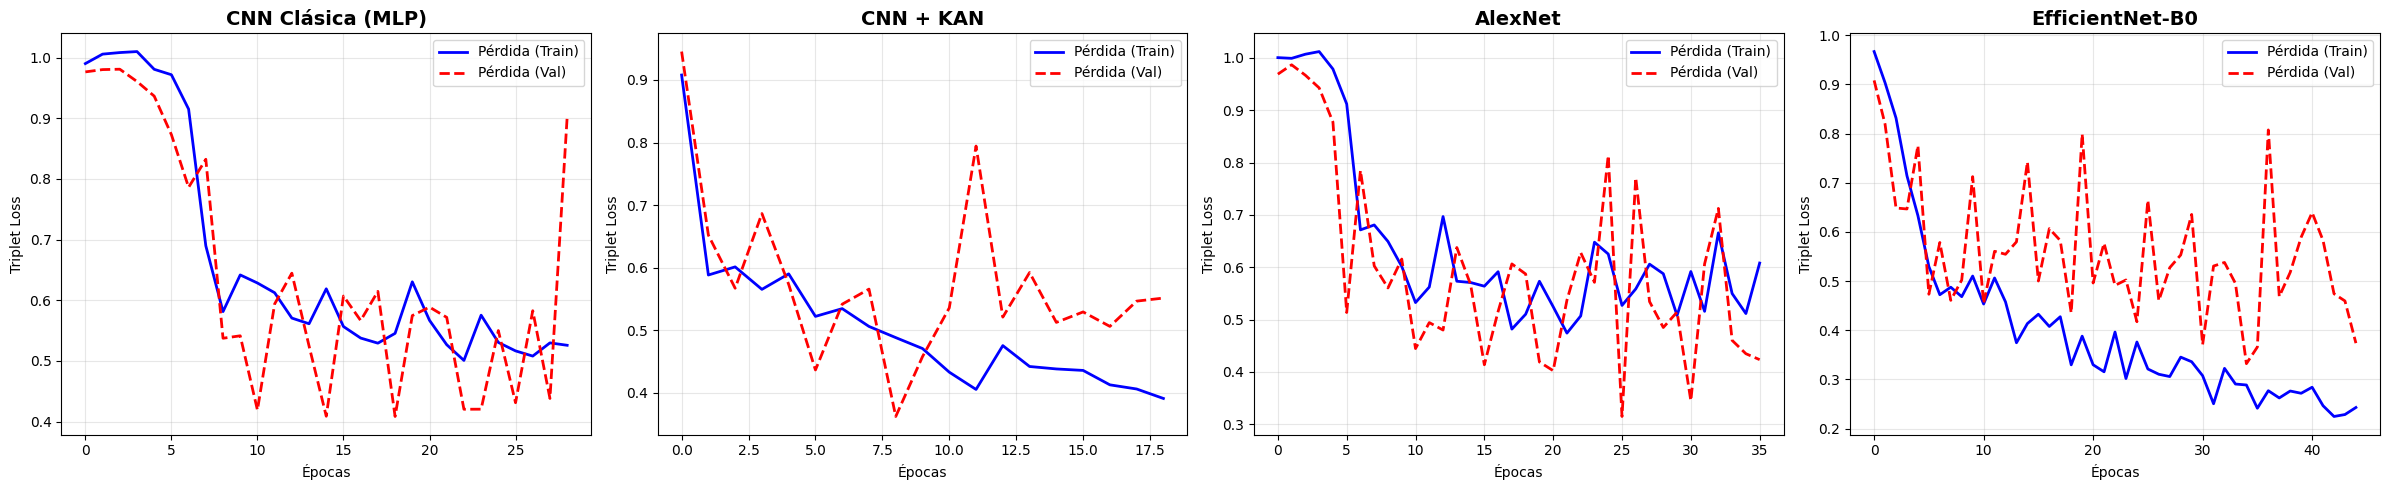

In [6]:
# 3.2 DEFINICIÓN DE TOPOLOGÍAS

# Arquitecturas neuronales
# ========================
# 1.CNN con MLP
class CNNClasicaFingerprint(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.ext=nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveMaxPool2d((4, 4))
        )
        self.proj=nn.Sequential(nn.Linear(128 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.4), nn.Linear(512, dim))
    def forward(self, x):
        return F.normalize(self.proj(self.ext(x).view(x.size(0), -1)), p=2, dim=1)


# 2.CNN con KAN
class CNN_KAN_Fingerprint(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        # Usamos EXACTAMENTE el mismo extractor que la CNN Clásica para que la comparativa sea justa
        self.ext = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveMaxPool2d((4, 4))
        )

        # LA MAGIA: Reemplazamos el MLP final (Linear -> ReLU -> Linear) por 2 capas KAN.
        # Las KAN ya no necesitan ReLU entre ellas, porque cada conexión ya es una función no lineal.
        self.kan1 = CapaKAN(128 * 4 * 4, 512, num_bases=5)
        self.kan2 = CapaKAN(512, dim, num_bases=5)

    def forward(self, x):
        x = self.ext(x).view(x.size(0), -1)
        x = self.kan1(x)
        x = self.kan2(x)
        return F.normalize(x, p=2, dim=1)

# 3.AlexNet
class AlexNetFingerprint(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.ext=nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(3, 2),
            nn.Conv2d(64, 192, 5, padding=2), nn.BatchNorm2d(192), nn.ReLU(), nn.MaxPool2d(3, 2),
            nn.Conv2d(192, 384, 3, padding=1), nn.ReLU(), nn.Conv2d(384, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(), nn.AdaptiveMaxPool2d((4, 4))
        )
        self.proj=nn.Sequential(nn.Dropout(0.5), nn.Linear(256 * 4 * 4, 1024), nn.ReLU(), nn.Dropout(0.5), nn.Linear(1024, dim))
    def forward(self, x):
        return F.normalize(self.proj(self.ext(x).view(x.size(0), -1)), p=2, dim=1)

# 4.EfficientNet
class EfficientNetFingerprint(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.backbone=models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        # Transformación algebraica para procesar 1 canal sin perder pesos preentrenados
        c_orig=self.backbone.features[0][0]
        c_nueva=nn.Conv2d(1, c_orig.out_channels, c_orig.kernel_size, c_orig.stride, c_orig.padding, bias=False)
        c_nueva.weight.data=torch.sum(c_orig.weight.data, dim=1, keepdim=True)
        self.backbone.features[0][0]=c_nueva
        self.backbone.classifier=nn.Sequential(nn.Dropout(p=0.3, inplace=True), nn.Linear(self.backbone.classifier[1].in_features, dim))
    def forward(self, x):
        return F.normalize(self.backbone(x), p=2, dim=1)



# Motor común de entrenamiento
# ============================
def entrenar_y_evaluar(modelo, nombre, lr, weight_decay=0):
    print(f"\n" + "="*50)
    print(f" Arquitectura: {nombre}")
    print("="*50)
    # Fase de entrenamiento (Early Stopping)
    optimizador=optim.AdamW(modelo.parameters(), lr=lr, weight_decay=weight_decay)
    criterio=nn.TripletMarginLoss(margin=1.0, p=2)

    paciencia, contador=10, 0
    mejor_val=float('inf')
    mejores_pesos=None
    historial={'train': [], 'val': []}

    for epoch in range(500):
        modelo.train()
        loss_t_acum=0
        for a, p, n in dataloader_train:
            optimizador.zero_grad()
            l=criterio(modelo(a.to(device)), modelo(p.to(device)), modelo(n.to(device)))
            l.backward()
            optimizador.step()
            loss_t_acum += l.item()

        modelo.eval()
        loss_v_acum=0
        with torch.no_grad():
            for a, p, n in dataloader_val:
                loss_v_acum += criterio(modelo(a.to(device)), modelo(p.to(device)), modelo(n.to(device))).item()

        l_t, l_v=loss_t_acum/len(dataloader_train), loss_v_acum/len(dataloader_val)
        historial['train'].append(l_t); historial['val'].append(l_v)
        print(f"Época {epoch+1:02d} | Train Loss: {l_t:.4f} | Val Loss: {l_v:.4f}\n", end="")

        if l_v < mejor_val:
            mejor_val, contador=l_v, 0
            mejores_pesos=copy.deepcopy(modelo.state_dict())
        else:
            contador += 1
            print(f" Paciencia {contador}/{paciencia}")
            if contador >= paciencia:
                print(f" Early Stopping activado en época {epoch+1}")
                break
    modelo.load_state_dict(mejores_pesos)

    # Fase de test
    print(f"\n   RESULTADOS FINALES ({nombre}) ")
    aciertos, pruebas=0, min(50, len(dataset_test))
    sim_p, sim_n=[], []

    with torch.no_grad():
        for _ in range(pruebas):
            a, p, n = dataset_test[random.randint(0, len(dataset_test)-1)]
            ha, hp, hn = modelo(a.unsqueeze(0).to(device)), modelo(p.unsqueeze(0).to(device)), modelo(n.unsqueeze(0).to(device))
            sp, sn = F.cosine_similarity(ha, hp).item()*100, F.cosine_similarity(ha, hn).item()*100
            sim_p.append(sp); sim_n.append(sn)
            if sp > sn: aciertos += 1

    print(f"  - Precisión Topológica: {(aciertos/pruebas)*100:.2f}%")
    print(f"  - Similitud Plagios: {sum(sim_p)/pruebas:.2f}%")
    print(f"  - Similitud Randoms: {sum(sim_n)/pruebas:.2f}%")
    return historial


# Ejecución de los 4 experimentos
# ===============================
if len(dataset_train) > 0:

    # 1. CNN Clásica (con MLP)
    torch.manual_seed(42)
    modelo_cnn = CNNClasicaFingerprint().to(device)
    hist_cnn = entrenar_y_evaluar(modelo_cnn, "CNN Clásica (MLP)", lr=0.001)

    # 2. CNN + KAN
    torch.manual_seed(42)
    modelo_kan = CNN_KAN_Fingerprint().to(device)
    # KAN necesita un learning rate un poco más pequeño para estabilizar sus funciones senoidales
    hist_kan = entrenar_y_evaluar(modelo_kan, "CNN + KAN", lr=0.0005)

    # 3. AlexNet
    torch.manual_seed(42)
    modelo_alex = AlexNetFingerprint().to(device)
    hist_alex = entrenar_y_evaluar(modelo_alex, "AlexNet", lr=0.0005)

    # 4. EfficientNet
    torch.manual_seed(42)
    modelo_eff = EfficientNetFingerprint().to(device)
    hist_eff = entrenar_y_evaluar(modelo_eff, "EfficientNet-B0", lr=0.0001, weight_decay=1e-4)

    # Visualización (Ajustamos para 4 gráficas)
    fig, ejes = plt.subplots(1, 4, figsize=(24, 5))
    graficas = [
        ("CNN Clásica (MLP)", hist_cnn),
        ("CNN + KAN", hist_kan),
        ("AlexNet", hist_alex),
        ("EfficientNet-B0", hist_eff)
    ]

    for idx, (nombre, hist) in enumerate(graficas):
        ejes[idx].plot(hist['train'], label='Pérdida (Train)', color='blue', linewidth=2)
        ejes[idx].plot(hist['val'], label='Pérdida (Val)', color='red', linestyle='--', linewidth=2)
        ejes[idx].set_title(f'{nombre}', fontsize=14, fontweight='bold')
        ejes[idx].set_xlabel('Épocas')
        ejes[idx].set_ylabel('Triplet Loss')
        ejes[idx].legend()
        ejes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 3.3. Clasificación con autoencoder
A continuación realizaremos nuevamente la clasificación sobre el dataset comprimido. Para ello, entrenaremos un Autoencoder con el dataset que nos permita comprimir los espectrogramas a imagenes en un espacio latente de tamaño 16×16. Una vez comprimido se realizará nuevamente la comparación entre las diferentes arquitecturas para la evaluación de similitud entre canciones.

In [7]:
# AUTOENCODER

# 1. PREPARACIÓN Y CONFIGURACIÓN
# ===============================
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Motor de cálculo activado: {device}")

RUTA_DATASET = '/content/dataset_Espectrogramas_Local'
RUTA_COMPRIMIDOS = '/content/dataset_Comprimido_16x16'

if not os.path.exists(RUTA_COMPRIMIDOS):
    os.makedirs(RUTA_COMPRIMIDOS)
    print(f"Carpeta creada para el nuevo dataset: {RUTA_COMPRIMIDOS}")

# 2. DATASET SIMPLE PARA EL AUTOENCODER
# =====================================================================
class SpectrogramAutoencoderDataset(Dataset):
    def __init__(self, ruta_carpeta):
        self.ruta = ruta_carpeta
        self.archivos = [f for f in os.listdir(ruta_carpeta) if f.endswith('.png')]

        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        nombre_archivo = self.archivos[idx]
        img_path = os.path.join(self.ruta, nombre_archivo)
        imagen = self.transform(Image.open(img_path))
        return imagen, nombre_archivo

dataset_ae = SpectrogramAutoencoderDataset(RUTA_DATASET)
dataloader_ae = DataLoader(dataset_ae, batch_size=32, shuffle=True)

# 3. ARQUITECTURA: AUTOENCODER CONVOLUCIONAL (256x256 -> 16x16)
# =====================================================================
class Autoencoder(nn.Module):
    def __init__(self, canales_latentes=8):
        super(Autoencoder, self).__init__()

        # ENCODER: 1x256x256 -> C_latentes x 16 x 16
        self.encoder = nn.Sequential(
            # 256x256 -> 128x128
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # 128x128 -> 64x64
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # 64x64 -> 32x32
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            # 32x32 -> 16x16
            nn.Conv2d(64, canales_latentes, kernel_size=3, stride=2, padding=1),
            nn.Tanh()
        )

        # DECODER: C_latentes x 16 x 16 -> 1x256x256
        self.decoder = nn.Sequential(
            # 16x16 -> 32x32
            nn.ConvTranspose2d(canales_latentes, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # 32x32 -> 64x64
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # 64x64 -> 128x128
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            # 128x128 -> 256x256
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        latente = self.encoder(x)
        reconstruccion = self.decoder(latente)
        return reconstruccion, latente

# Aumentamos a 8 canales latentes. El tensor será [8, 16, 16]
modelo_ae = Autoencoder(canales_latentes=8).to(device)
criterio = nn.MSELoss()
optimizador = optim.Adam(modelo_ae.parameters(), lr=0.001)

# 4. ENTRENAMIENTO DEL AUTOENCODER
# =====================================================================
epocas = 30
modelo_ae.train()

for epoch in range(epocas):
    loss_acum = 0
    for imagenes, _ in dataloader_ae:
        imagenes = imagenes.to(device)

        optimizador.zero_grad()
        salida, _ = modelo_ae(imagenes)

        loss = criterio(salida, imagenes)
        loss.backward()
        optimizador.step()

        loss_acum += loss.item()

    print(f"Época {epoch+1}/{epocas} | MSE Loss: {loss_acum/len(dataloader_ae):.4f}")

print("\n--- Guardando pesos del Autoencoder ---")
torch.save(modelo_ae.state_dict(), 'pesos_autoencoder.pth')

# 5. GENERACIÓN Y GUARDADO DEL NUEVO DATASET COMPRIMIDO
# =====================================================================
print("\n--- Comprimiendo el dataset y guardando tensores ---")
dataloader_guardado = DataLoader(dataset_ae, batch_size=1, shuffle=False)

modelo_ae.eval()
with torch.no_grad():
    for imagen, nombre_archivo in dataloader_guardado:
        imagen = imagen.to(device)
        nombre = nombre_archivo[0]

        _, latente = modelo_ae(imagen)

        # El tamaño aquí será [1, 8, 16, 16]
        nombre_base = nombre.replace('.png', '.pt')
        ruta_guardado = os.path.join(RUTA_COMPRIMIDOS, nombre_base)

        torch.save(latente.cpu().squeeze(0), ruta_guardado)

print(f"\nDATASET COMPRIMIDO")
print(f"Las {len(dataset_ae)} canciones se han reducido a tensores de tamaño [8, 16, 16]")
print(f"Archivos guardados en: {RUTA_COMPRIMIDOS}")

Motor de cálculo activado: cuda
Carpeta creada para el nuevo dataset: /content/dataset_Comprimido_16x16
Época 1/30 | MSE Loss: 0.2021
Época 2/30 | MSE Loss: 0.0780
Época 3/30 | MSE Loss: 0.0534
Época 4/30 | MSE Loss: 0.0429
Época 5/30 | MSE Loss: 0.0359
Época 6/30 | MSE Loss: 0.0322
Época 7/30 | MSE Loss: 0.0298
Época 8/30 | MSE Loss: 0.0279
Época 9/30 | MSE Loss: 0.0267
Época 10/30 | MSE Loss: 0.0259
Época 11/30 | MSE Loss: 0.0258
Época 12/30 | MSE Loss: 0.0250
Época 13/30 | MSE Loss: 0.0248
Época 14/30 | MSE Loss: 0.0244
Época 15/30 | MSE Loss: 0.0240
Época 16/30 | MSE Loss: 0.0240
Época 17/30 | MSE Loss: 0.0234
Época 18/30 | MSE Loss: 0.0229
Época 19/30 | MSE Loss: 0.0221
Época 20/30 | MSE Loss: 0.0218
Época 21/30 | MSE Loss: 0.0215
Época 22/30 | MSE Loss: 0.0212
Época 23/30 | MSE Loss: 0.0211
Época 24/30 | MSE Loss: 0.0211
Época 25/30 | MSE Loss: 0.0209
Época 26/30 | MSE Loss: 0.0206
Época 27/30 | MSE Loss: 0.0206
Época 28/30 | MSE Loss: 0.0208
Época 29/30 | MSE Loss: 0.0204
Época 

In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. DATASET BINARIO: El Detective (0 = Original, 1 = IA)
# =====================================================================
class SpectrogramBinaryDataset(Dataset):
    def __init__(self, ruta_carpeta):
        self.ruta = ruta_carpeta
        self.archivos = [f for f in os.listdir(ruta_carpeta) if f.endswith('.png')]
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((256, 256)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self): return len(self.archivos)

    def __getitem__(self, idx):
        nombre_archivo = self.archivos[idx]
        img_path = os.path.join(self.ruta, nombre_archivo)
        imagen = self.transform(Image.open(img_path))

        if 'ia' in nombre_archivo.lower() or 'cover' in nombre_archivo.lower():
            etiqueta = 1.0  # 1.0 significa "Es un cover o IA"
        else:
            etiqueta = 0.0  # 0.0 significa "Es Original"

        return imagen, torch.tensor([etiqueta], dtype=torch.float32)

dataset_binario = SpectrogramBinaryDataset(RUTA_DATASET)
dataloader_binario = DataLoader(dataset_binario, batch_size=16, shuffle=True)

# 2. EL MODELO DEFINITIVO
# =====================================================================
class ClasificadorIA(nn.Module):
    def __init__(self):
        super().__init__()
        # Extracción de características (Basada en tu Autoencoder inicial)
        self.ext = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), nn.ReLU(), nn.AdaptiveMaxPool2d((4, 4))
        )
        # La capa de Decisión Binaria
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1),
            nn.Sigmoid() # <--- La clave: Fuerza la salida a ser un % entre 0 y 1
        )

    def forward(self, x):
        return self.clasificador(self.ext(x))

# 3. ENTRENAMIENTO
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_ia = ClasificadorIA().to(device)
optimizador = optim.Adam(modelo_ia.parameters(), lr=0.001)
criterio = nn.BCELoss() # Binary Cross Entropy (Para decir SI o NO)

epocas = 20 # Puedes subirlo a 30 o 40 si quieres que sea más preciso
print("\n--- Iniciando entrenamiento del Clasificador de IA ---")
for epoch in range(epocas):
    modelo_ia.train()
    loss_acum = 0
    for imagenes, etiquetas in dataloader_binario:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)

        optimizador.zero_grad()
        salida = modelo_ia(imagenes)

        loss = criterio(salida, etiquetas)
        loss.backward()
        optimizador.step()
        loss_acum += loss.item()

    print(f"Época {epoch+1}/{epocas} | Pérdida: {loss_acum/len(dataloader_binario):.4f}")

# 4. GUARDADO
# =====================================================================
torch.save(modelo_ia.state_dict(), 'pesos_clasificador.pth')
print("\nPesos guardados: Descarga el archivo 'pesos_clasificador.pth'")


--- Iniciando entrenamiento del Clasificador de IA ---
Época 1/20 | Pérdida: 0.2107
Época 2/20 | Pérdida: 0.1643
Época 3/20 | Pérdida: 0.1412
Época 4/20 | Pérdida: 0.1280
Época 5/20 | Pérdida: 0.1363
Época 6/20 | Pérdida: 0.1559
Época 7/20 | Pérdida: 0.1428
Época 8/20 | Pérdida: 0.1455
Época 9/20 | Pérdida: 0.1330
Época 10/20 | Pérdida: 0.1358
Época 11/20 | Pérdida: 0.1404
Época 12/20 | Pérdida: 0.1290
Época 13/20 | Pérdida: 0.1320
Época 14/20 | Pérdida: 0.1194
Época 15/20 | Pérdida: 0.1345
Época 16/20 | Pérdida: 0.1224
Época 17/20 | Pérdida: 0.1149
Época 18/20 | Pérdida: 0.1072
Época 19/20 | Pérdida: 0.0985
Época 20/20 | Pérdida: 0.0862

Pesos guardados: Descarga el archivo 'pesos_clasificador.pth'


Una vez entrenado el Autoencoder y preparado el dataset comprimido, repetimos el entrenamiento de las estructuras de clasificación.

 - [Modo TRAIN] Universo : 352 canciones | Válidas para Tríos: 152
 - [Modo TEST] Universo : 89 canciones | Válidas para Tríos: 35
Motor de cálculo activado: cuda

 Arquitectura: CNN Clásica (MLP)
Época 01 | Train Loss: 0.8498 | Val Loss: 0.6523
Época 02 | Train Loss: 0.5933 | Val Loss: 0.9384
Época 03 | Train Loss: 0.6036 | Val Loss: 0.5899
Época 04 | Train Loss: 0.5520 | Val Loss: 0.7973
Época 05 | Train Loss: 0.5798 | Val Loss: 0.3552
Época 06 | Train Loss: 0.5610 | Val Loss: 0.4795
Época 07 | Train Loss: 0.5824 | Val Loss: 0.4976
Época 08 | Train Loss: 0.5787 | Val Loss: 0.6218
Época 09 | Train Loss: 0.5478 | Val Loss: 0.4054
Época 10 | Train Loss: 0.6061 | Val Loss: 0.6638
Época 11 | Train Loss: 0.5538 | Val Loss: 0.8692
Época 12 | Train Loss: 0.4066 | Val Loss: 0.5131
Época 13 | Train Loss: 0.5220 | Val Loss: 0.4323
Época 14 | Train Loss: 0.4783 | Val Loss: 0.2406
Época 15 | Train Loss: 0.5400 | Val Loss: 0.4365
Época 16 | Train Loss: 0.4701 | Val Loss: 0.4200
Época 17 | Train Lo

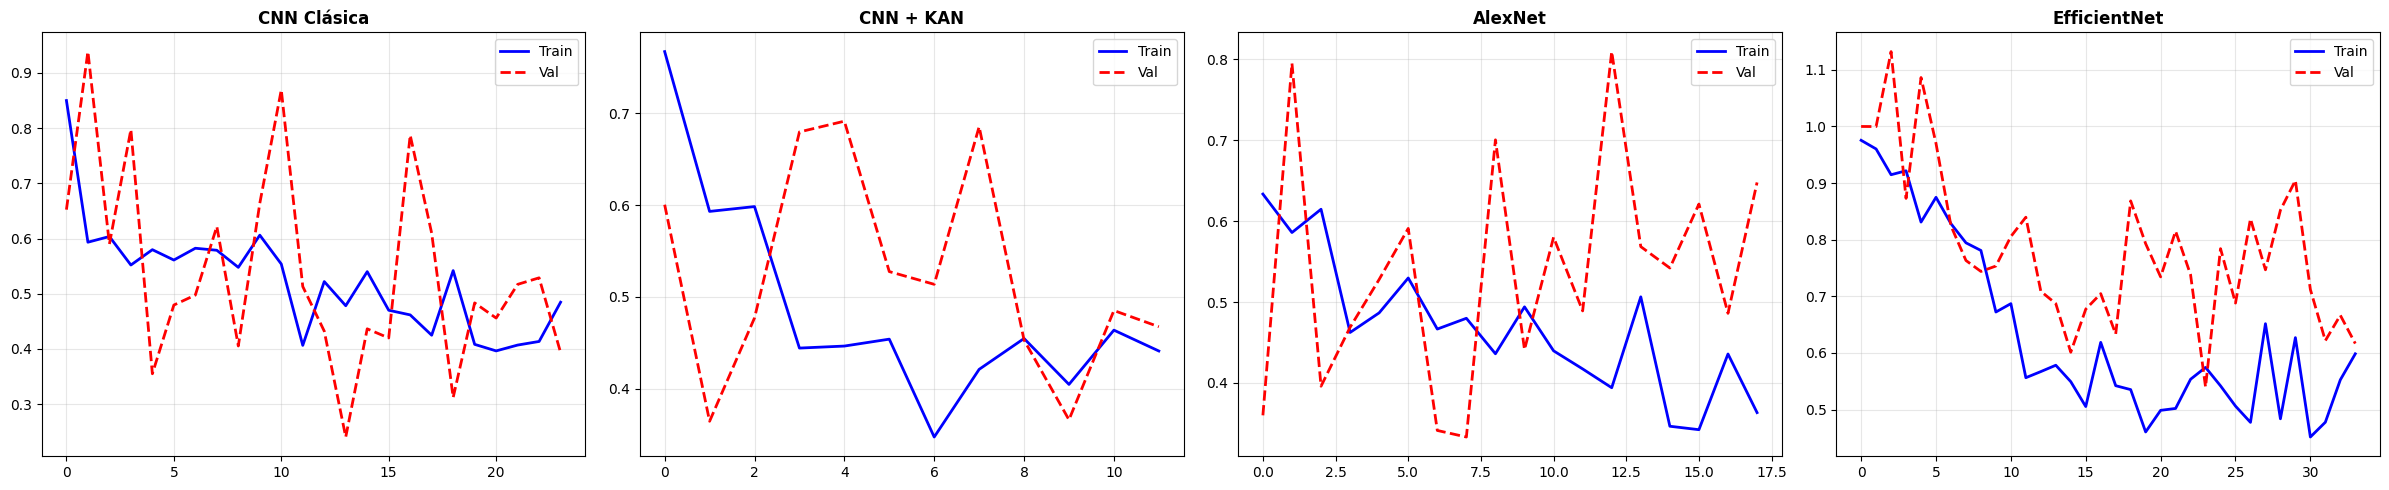

In [9]:
# REPETICIÓN 3.1 PREPARACIÓN DEL ESPACIO DE DATOS (VERSIÓN LATENTE)
# =====================================================================
import os
import random
import re
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

RUTA_LATENTES = '/content/dataset_Comprimido_16x16'

class LatentSpectrogramDataset(Dataset):
    def __init__(self, ruta_carpeta, modo="train", particion_train=0.8):
        self.ruta = ruta_carpeta
        self.archivos = [f for f in os.listdir(ruta_carpeta) if f.endswith('.pt')]
        self.modo = modo

        self.agrupacion_canciones = self._agrupar_por_cancion()
        todas_las_canciones = list(self.agrupacion_canciones.keys())
        todas_las_canciones.sort()
        random.Random(42).shuffle(todas_las_canciones)

        corte = int(len(todas_las_canciones) * particion_train)
        self.mis_canciones = todas_las_canciones[:corte] if self.modo == "train" else todas_las_canciones[corte:]
        self.lista_ids_validos = [k for k in self.mis_canciones if len(self.agrupacion_canciones[k]) >= 2]

        print(f" - [Modo {self.modo.upper()}] Universo : {len(self.mis_canciones)} canciones | Válidas para Tríos: {len(self.lista_ids_validos)}")

    def _agrupar_por_cancion(self):
        grupos = {}
        for f in self.archivos:
            nombre = f.replace('.pt', '')
            if " - " in nombre: nombre = nombre.split(" - ", 1)[1]
            nombre_limpio = re.sub(r'[\s_]*\(?V[-A-Z]+\)?$', '', nombre).strip()
            if nombre_limpio not in grupos: grupos[nombre_limpio] = []
            grupos[nombre_limpio].append(f)
        return grupos

    def __len__(self): return len(self.lista_ids_validos)

    def __getitem__(self, idx):
        id_actual = self.lista_ids_validos[idx]
        variantes = self.agrupacion_canciones[id_actual]
        v_anc, v_pos = random.sample(variantes, 2)

        id_neg = random.choice([i for i in self.mis_canciones if i != id_actual])
        v_neg = random.choice(self.agrupacion_canciones[id_neg])

        t_anc = torch.load(os.path.join(self.ruta, v_anc), weights_only=True)
        t_pos = torch.load(os.path.join(self.ruta, v_pos), weights_only=True)
        t_neg = torch.load(os.path.join(self.ruta, v_neg), weights_only=True)

        return t_anc, t_pos, t_neg

dataset_train = LatentSpectrogramDataset(RUTA_LATENTES, modo="train")
dataset_test = LatentSpectrogramDataset(RUTA_LATENTES, modo="test")
dataloader_train = DataLoader(dataset_train, batch_size=16, shuffle=True)
dataloader_val = DataLoader(dataset_test, batch_size=16, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Motor de cálculo activado: {device}")


# CAPA KAN
class CapaKAN(nn.Module):
    def __init__(self, in_features, out_features, num_bases=5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_bases = num_bases
        self.pesos_base = nn.Parameter(torch.Tensor(out_features, in_features, num_bases))
        self.pesos_lineales = nn.Parameter(torch.Tensor(out_features, in_features))
        nn.init.kaiming_uniform_(self.pesos_base, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.pesos_lineales, a=math.sqrt(5))

    def forward(self, x):
        salida_lineal = F.linear(F.silu(x), self.pesos_lineales)
        n = torch.arange(1, self.num_bases + 1, device=x.device).float()
        bases = torch.sin(x.unsqueeze(-1) * n)
        bases_flat = bases.view(x.size(0), -1)
        pesos_flat = self.pesos_base.view(self.out_features, -1)
        salida_kan = F.linear(bases_flat, pesos_flat)
        return salida_lineal + salida_kan


# 3.2 TOPOLOGÍAS ADAPTADAS AL ESPACIO LATENTE [8, 16, 16]
# =====================================================================

# 1. CNN con MLP
class CNNClasicaFingerprint(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.ext = nn.Sequential(
            nn.Conv2d(8, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            # 8x8 -> 4x4
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            # 4x4 -> 4x4
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveMaxPool2d((4, 4))
        )
        self.proj = nn.Sequential(nn.Linear(128 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.4), nn.Linear(512, dim))
    def forward(self, x):
        return F.normalize(self.proj(self.ext(x).view(x.size(0), -1)), p=2, dim=1)

# 2. CNN con KAN
class CNN_KAN_Fingerprint(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.ext = nn.Sequential(
            nn.Conv2d(8, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveMaxPool2d((4, 4))
        )
        self.kan1 = CapaKAN(128 * 4 * 4, 512, num_bases=5)
        self.kan2 = CapaKAN(512, dim, num_bases=5)
    def forward(self, x):
        x = self.ext(x).view(x.size(0), -1)
        x = self.kan1(x)
        x = self.kan2(x)
        return F.normalize(x, p=2, dim=1)

# 3. AlexNet Modificada y Estabilizada
class AlexNetFingerprint(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.ext = nn.Sequential(
            nn.Conv2d(8, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 192, 3, padding=1), nn.BatchNorm2d(192), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(192, 384, 3, padding=1), nn.ReLU(),
            nn.Conv2d(384, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2))
        )

        self.proj = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, dim)
        )

    def forward(self, x):
        return F.normalize(self.proj(self.ext(x).view(x.size(0), -1)), p=2, dim=1)

# 4. EfficientNet Adaptado
class EfficientNetFingerprint(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights=None)

        c_orig = self.backbone.features[0][0]
        c_nueva = nn.Conv2d(8, c_orig.out_channels, c_orig.kernel_size, c_orig.stride, c_orig.padding, bias=False)
        self.backbone.features[0][0] = c_nueva
        self.backbone.classifier = nn.Sequential(nn.Dropout(p=0.3, inplace=True), nn.Linear(self.backbone.classifier[1].in_features, dim))

    def forward(self, x):
        x = F.interpolate(x, size=(64, 64), mode='bilinear', align_corners=False)
        return F.normalize(self.backbone(x), p=2, dim=1)

# BUCLE DE ENTRENAMIENTO
# =====================================================================
def entrenar_y_evaluar(modelo, nombre, lr, weight_decay=0):
    print(f"\n" + "="*50)
    print(f" Arquitectura: {nombre}")
    print("="*50)
    optimizador = optim.AdamW(modelo.parameters(), lr=lr, weight_decay=weight_decay)
    criterio = nn.TripletMarginLoss(margin=1.0, p=2)

    paciencia, contador = 10, 0
    mejor_val = float('inf')
    mejores_pesos = None
    historial = {'train': [], 'val': []}

    for epoch in range(500):
        modelo.train()
        loss_t_acum = 0
        for a, p, n in dataloader_train:
            optimizador.zero_grad()
            l = criterio(modelo(a.to(device)), modelo(p.to(device)), modelo(n.to(device)))
            l.backward()
            optimizador.step()
            loss_t_acum += l.item()

        modelo.eval()
        loss_v_acum = 0
        with torch.no_grad():
            for a, p, n in dataloader_val:
                loss_v_acum += criterio(modelo(a.to(device)), modelo(p.to(device)), modelo(n.to(device))).item()

        l_t, l_v = loss_t_acum/len(dataloader_train), loss_v_acum/len(dataloader_val)
        historial['train'].append(l_t); historial['val'].append(l_v)
        print(f"Época {epoch+1:02d} | Train Loss: {l_t:.4f} | Val Loss: {l_v:.4f}\n", end="")

        if l_v < mejor_val:
            mejor_val, contador = l_v, 0
            mejores_pesos = copy.deepcopy(modelo.state_dict())
        else:
            contador += 1
            if contador >= paciencia:
                print(f" Early Stopping activado en época {epoch+1}")
                break

    modelo.load_state_dict(mejores_pesos)

    modelo.eval()
    print(f"\n   RESULTADOS FINALES ({nombre}) ")
    aciertos, pruebas = 0, min(50, len(dataset_test))
    sim_p, sim_n = [], []

    with torch.no_grad():
        for _ in range(pruebas):
            a, p, n = dataset_test[random.randint(0, len(dataset_test)-1)]
            ha, hp, hn = modelo(a.unsqueeze(0).to(device)), modelo(p.unsqueeze(0).to(device)), modelo(n.unsqueeze(0).to(device))
            sp, sn = F.cosine_similarity(ha, hp).item()*100, F.cosine_similarity(ha, hn).item()*100
            sim_p.append(sp); sim_n.append(sn)
            if sp > sn: aciertos += 1

    print(f"  - Precisión Topológica: {(aciertos/pruebas)*100:.2f}%")
    print(f"  - Similitud Plagios: {sum(sim_p)/pruebas:.2f}%")
    print(f"  - Similitud Randoms: {sum(sim_n)/pruebas:.2f}%")
    return historial

# EJECUCIÓN
# ===============================
if len(dataset_train) > 0:
    torch.manual_seed(42)
    modelo_cnn = CNNClasicaFingerprint().to(device)
    hist_cnn = entrenar_y_evaluar(modelo_cnn, "CNN Clásica (MLP)", lr=0.001)

    torch.manual_seed(42)
    modelo_kan = CNN_KAN_Fingerprint().to(device)
    hist_kan = entrenar_y_evaluar(modelo_kan, "CNN + KAN", lr=0.0005)

    torch.manual_seed(42)
    modelo_alex = AlexNetFingerprint().to(device)
    hist_alex = entrenar_y_evaluar(modelo_alex, "AlexNet", lr=0.0005)

    torch.manual_seed(42)
    modelo_eff = EfficientNetFingerprint().to(device)
    hist_eff = entrenar_y_evaluar(modelo_eff, "EfficientNet-B0", lr=0.0001, weight_decay=1e-4)

    fig, ejes = plt.subplots(1, 4, figsize=(24, 5))
    graficas = [("CNN Clásica", hist_cnn), ("CNN + KAN", hist_kan), ("AlexNet", hist_alex), ("EfficientNet", hist_eff)]

    for idx, (nombre, hist) in enumerate(graficas):
        ejes[idx].plot(hist['train'], label='Train', color='blue', linewidth=2)
        ejes[idx].plot(hist['val'], label='Val', color='red', linestyle='--', linewidth=2)
        ejes[idx].set_title(nombre, fontweight='bold')
        ejes[idx].legend()
        ejes[idx].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 3.4. Anatomía del Neural Fingerprint (El Código de Barras Acústico)

Para comprender qué está haciendo exactamente la red neuronal, podemos visualizar el *Fingerprint* (el vector $v \in \mathbb{R}^{128}$) generado por la capa latente.

Al proyectar estos vectores como mapas de calor bidimensionales, podemos observar visualmente el efecto de la *Triplet Loss*. A continuación, extraemos una canción original, su versión/plagio y una pista aleatoria del conjunto de Test, y comparamos sus firmas topológicas. Si el entrenamiento ha sido exitoso, los "códigos de barras" de la canción original y el cover deberían tener un patrón de activación casi idéntico (alta similitud del coseno), mientras que la canción aleatoria mostrará un patrón ortogonal.

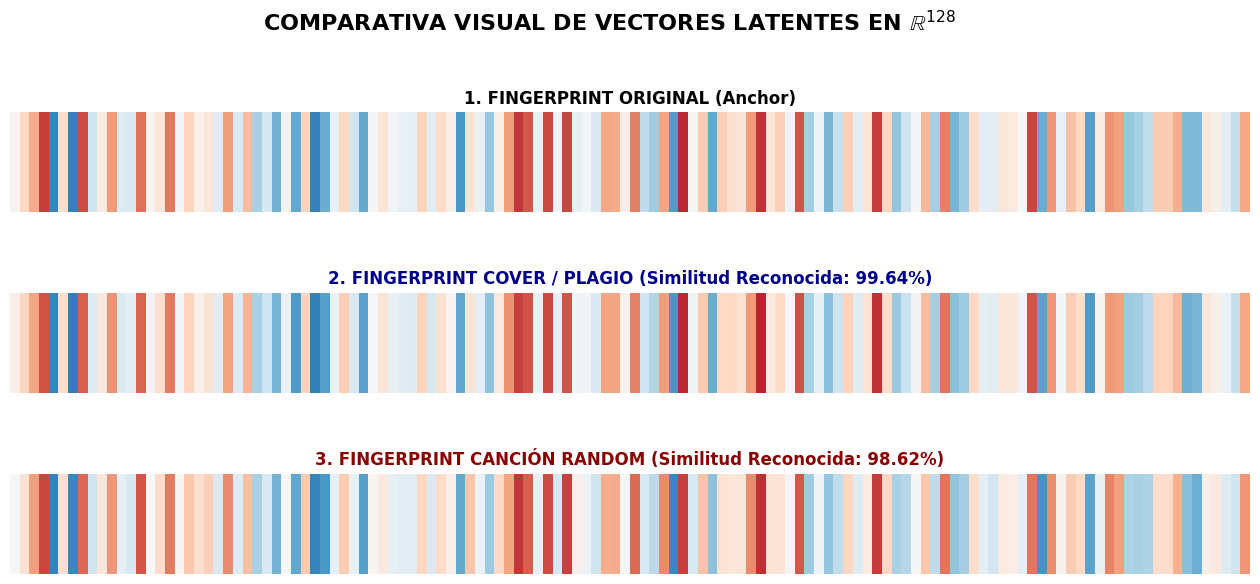

In [10]:
import seaborn as sns

# Usaremos el modelo EfficientNet
modelo_eff.eval()

with torch.no_grad():
    # 1. Extraemos un trío aleatorio
    idx_random=random.randint(0, len(dataset_test) - 1)
    anchor_img, positive_img, negative_img=dataset_test[idx_random]

    # 2. Pasamos las imágenes por la red para generar los Fingerprints (vectores 128D)
    fp_anchor=modelo_eff(anchor_img.unsqueeze(0).to(device)).cpu().numpy()
    fp_positive=modelo_eff(positive_img.unsqueeze(0).to(device)).cpu().numpy()
    fp_negative=modelo_eff(negative_img.unsqueeze(0).to(device)).cpu().numpy()

# 3. Calculamos la similitud del coseno real
similitud_plagio=np.dot(fp_anchor.flatten(), fp_positive.flatten()) * 100
similitud_random=np.dot(fp_anchor.flatten(), fp_negative.flatten()) * 100

# 4. Gráfico
fig, ejes=plt.subplots(3, 1, figsize=(16, 6), gridspec_kw={'hspace': 0.8})
cmap='RdBu'
rango=0.25
sns.heatmap(fp_anchor, ax=ejes[0], cmap=cmap, cbar=False, vmin=-rango, vmax=rango, xticklabels=False, yticklabels=False)
ejes[0].set_title("1. FINGERPRINT ORIGINAL (Anchor)", fontsize=12, fontweight='bold', color='black')
sns.heatmap(fp_positive, ax=ejes[1], cmap=cmap, cbar=False, vmin=-rango, vmax=rango, xticklabels=False, yticklabels=False)
ejes[1].set_title(f"2. FINGERPRINT COVER / PLAGIO (Similitud Reconocida: {similitud_plagio:.2f}%)", fontsize=12, fontweight='bold', color='darkblue')
sns.heatmap(fp_negative, ax=ejes[2], cmap=cmap, cbar=False, vmin=-rango, vmax=rango, xticklabels=False, yticklabels=False)
ejes[2].set_title(f"3. FINGERPRINT CANCIÓN RANDOM (Similitud Reconocida: {similitud_random:.2f}%)", fontsize=12, fontweight='bold', color='darkred')
plt.suptitle("COMPARATIVA VISUAL DE VECTORES LATENTES EN $\\mathbb{R}^{128}$", fontsize=16, fontweight='black', y=1.05)
plt.show()

Para descargar la CNN y el autoencoder:

In [11]:
import torch
from google.colab import files

# 1. Guardemos los pesos del autoencoder
torch.save(modelo_ae.state_dict(), 'autoencoder.pth')
files.download('autoencoder.pth')

# 2. Guardemos los pesos de la CNN (utilicemos EfficientNet, que es la más precisa en tu código)
torch.save(modelo_eff.state_dict(), 'cnn_fingerprint.pth')
files.download('cnn_fingerprint.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
